# Analysis of Results



In [1]:
import pandas as pd
import json
from pathlib import Path
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
import csv
from dotenv import load_dotenv
import os
import qvarnet
load_dotenv()  # Load environment variables from .env file
print(os.getcwd())
if os.getenv('MOUNTPOINT') is None:
    raise ValueError("MOUNTPOINT environment variable is not set.")
import utils

/home/pfargas/Desktop/PhD/data_analysis


## Change to the directory where the results are stored

In [2]:
os.chdir(os.getenv('MOUNTPOINT'))

## Data loading and processing

### Loading results in a dataframe

In [3]:
def load_results(parquet_dir:str, parquet_name: str, data_path:str) -> pd.DataFrame:
    if parquet_name not in os.listdir(parquet_dir):
        df = utils.load_simulation_results(data_path)
        df.to_parquet(parquet_dir+"/"+parquet_name, engine="fastparquet")
    else:
        df = pd.read_parquet(parquet_dir+"/"+parquet_name, engine="fastparquet")
    return df

In [4]:
PARQUET_DIR = "/home/pfargas/Desktop/PhD/data_analysis"

df_zero_walkers = load_results(PARQUET_DIR, "results_ZERO_WALKERS.parquet", './out/20260225_123439')
df_normal_walkers = load_results(PARQUET_DIR, "results.parquet", './out/20260211_142926')

df_zero_walkers.head()

,seed,total_energy,std,training_time_seconds,best_score,path,model_type,model_architecture,model_activation,training_batch_size,training_num_epochs,sampler_type,sampler_step_size,sampler_chain_length,sampler_PBC,optimizer_type,optimizer_learning_rate
0,42,38.690849,9.106707,401.942217,56.904263,out/20260225_123439/config_64_hu_3_l_100_parti...,exponential-mlp-fourth-decay,"[100, 64, 64, 64, 1]",tanh,1000,5000,metropolis_hastings,0.05,125,20,adam,0.01
1,42,134.062271,15.575247,354.043097,165.212769,out/20260225_123439/config_64_hu_2_l_200_parti...,exponential-mlp-fourth-decay,"[200, 64, 64, 1]",tanh,500,5000,metropolis_hastings,0.10,125,20,adam,0.01
2,42,75.269241,16.169909,428.847117,107.609055,out/20260225_123439/config_32_hu_2_l_200_parti...,exponential-mlp-fourth-decay,"[200, 32, 32, 1]",tanh,1000,5000,metropolis_hastings,0.05,125,20,adam,0.01
3,42,38.597145,8.980019,204.885929,56.557182,out/20260225_123439/config_64_hu_3_l_100_parti...,exponential-mlp-fourth-decay,"[100, 64, 64, 64, 1]",tanh,500,5000,metropolis_hastings,0.05,125,20,adam,0.01
4,42,-0.086774,0.000000,394.899219,-0.086774,out/20260225_123439/config_128_hu_3_l_50_parti...,exponential-mlp-fourth-decay,"[50, 128, 128, 128, 1]",tanh,1000,5000,metropolis_hastings,0.05,125,20,adam,0.01


In [5]:
df_normal_walkers.head()

,seed,total_energy,std,training_time_seconds,best_score,path,model_type,model_architecture,model_activation,training_batch_size,training_num_epochs,sampler_type,sampler_step_size,sampler_chain_length,sampler_PBC,optimizer_type,optimizer_learning_rate
0,42,21.395267,3.152891,38.339563,27.701050,out/20260211_142926/config_8_hu_3_l_50_particl...,exponential-mlp-fourth-decay,"[50, 8, 8, 8, 1]",tanh,500,5000,metropolis_hastings,0.05,100,20,adam,0.001
1,42,5.650299,1.682009,27.508885,9.014318,out/20260211_142926/config_4_hu_3_l_10_particl...,exponential-mlp-fourth-decay,"[10, 4, 4, 4, 1]",tanh,1000,5000,metropolis_hastings,0.50,125,20,adam,0.001
2,42,4.518309,1.176057,16.415093,6.870423,out/20260211_142926/config_4_hu_1_l_10_particl...,exponential-mlp-fourth-decay,"[10, 4, 1]",tanh,500,5000,metropolis_hastings,0.05,125,20,adam,0.010
3,42,4.970542,1.889289,18.872814,8.749120,out/20260211_142926/config_8_hu_1_l_10_particl...,exponential-mlp-fourth-decay,"[10, 8, 1]",tanh,1000,5000,metropolis_hastings,0.05,150,20,adam,0.001
4,42,25.625671,2.646152,219.222425,30.917974,out/20260211_142926/config_32_hu_1_l_200_parti...,exponential-mlp-fourth-decay,"[200, 32, 1]",tanh,500,5000,metropolis_hastings,0.05,150,20,adam,0.001


### Cleaning and transforming the data

In [6]:
df_zero_walkers = utils.separate_input_dim_and_hidden_dim(df_zero_walkers)
df_zero_walkers = utils.add_energy_per_particle(df_zero_walkers)
df_zero_walkers = utils.clean_non_informative_columns(df_zero_walkers)

df_normal_walkers = utils.separate_input_dim_and_hidden_dim(df_normal_walkers)
df_normal_walkers = utils.add_energy_per_particle(df_normal_walkers)
df_normal_walkers = utils.clean_non_informative_columns(df_normal_walkers)

Column 'seed' has only 1 unique group size, dropping.
Column 'model_type' has only 1 unique group size, dropping.
Column 'model_activation' has only 1 unique group size, dropping.
Column 'training_num_epochs' has only 1 unique group size, dropping.
Column 'sampler_type' has only 1 unique group size, dropping.
Column 'sampler_PBC' has only 1 unique group size, dropping.
Column 'optimizer_type' has only 1 unique group size, dropping.
Column 'seed' has only 1 unique group size, dropping.
Column 'model_type' has only 1 unique group size, dropping.
Column 'model_activation' has only 1 unique group size, dropping.
Column 'training_num_epochs' has only 1 unique group size, dropping.
Column 'sampler_type' has only 1 unique group size, dropping.
Column 'sampler_PBC' has only 1 unique group size, dropping.
Column 'optimizer_type' has only 1 unique group size, dropping.


In [7]:
df_normal_walkers.head()

,total_energy,std,training_time_seconds,best_score,path,training_batch_size,sampler_step_size,sampler_chain_length,optimizer_learning_rate,input_dim,hidden_dim,energy_per_particle,std_energy_per_particle,best_score_per_particle
0,21.395267,3.152891,38.339563,27.701050,out/20260211_142926/config_8_hu_3_l_50_particl...,500,0.05,100,0.001,50,"[8, 8, 8]",0.427905,0.063058,0.554021
1,5.650299,1.682009,27.508885,9.014318,out/20260211_142926/config_4_hu_3_l_10_particl...,1000,0.50,125,0.001,10,"[4, 4, 4]",0.565030,0.168201,0.901432
2,4.518309,1.176057,16.415093,6.870423,out/20260211_142926/config_4_hu_1_l_10_particl...,500,0.05,125,0.010,10,[4],0.451831,0.117606,0.687042
3,4.970542,1.889289,18.872814,8.749120,out/20260211_142926/config_8_hu_1_l_10_particl...,1000,0.05,150,0.001,10,[8],0.497054,0.188929,0.874912
4,25.625671,2.646152,219.222425,30.917974,out/20260211_142926/config_32_hu_1_l_200_parti...,500,0.05,150,0.001,200,[32],0.128128,0.013231,0.154590


In [46]:
df_zero_walkers.groupby(["input_dim"]).head()

,total_energy,std,training_time_seconds,best_score,path,training_batch_size,sampler_step_size,sampler_chain_length,optimizer_learning_rate,input_dim,hidden_dim,energy_per_particle,std_energy_per_particle,best_score_per_particle
0,38.690849,9.106707,401.942217,56.904263,out/20260225_123439/config_64_hu_3_l_100_parti...,1000,0.05,125,0.0100,100,"[64, 64, 64]",0.386908,9.106707e-02,0.569043
1,134.062271,15.575247,354.043097,165.212769,out/20260225_123439/config_64_hu_2_l_200_parti...,500,0.10,125,0.0100,200,"[64, 64]",0.670311,7.787623e-02,0.826064
2,75.269241,16.169909,428.847117,107.609055,out/20260225_123439/config_32_hu_2_l_200_parti...,1000,0.05,125,0.0100,200,"[32, 32]",0.376346,8.084954e-02,0.538045
3,38.597145,8.980019,204.885929,56.557182,out/20260225_123439/config_64_hu_3_l_100_parti...,500,0.05,125,0.0100,100,"[64, 64, 64]",0.385971,8.980019e-02,0.565572
4,-0.086774,0.000000,394.899219,-0.086774,out/20260225_123439/config_128_hu_3_l_50_parti...,1000,0.05,125,0.0100,50,"[128, 128, 128]",-0.001735,0.000000e+00,-0.001735
5,17.520407,4.124712,51.038787,25.769833,out/20260225_123439/config_16_hu_2_l_50_partic...,1000,0.05,100,0.0100,50,"[16, 16]",0.350408,8.249425e-02,0.515397
6,82.584839,19.061079,1379.234907,120.707001,out/20260225_123439/config_128_hu_2_l_200_part...,1000,0.05,150,0.0001,200,"[128, 128]",0.412924,9.530540e-02,0.603535
7,75.816483,16.010080,226.682501,107.836639,out/20260225_123439/config_8_hu_3_l_200_partic...,500,0.05,125,0.0100,200,"[8, 8, 8]",0.379082,8.005040e-02,0.539183
8,83.770615,18.945177,250.031941,121.660965,out/20260225_123439/config_8_hu_2_l_200_partic...,500,0.05,150,0.0100,200,"[8, 8]",0.418853,9.472589e-02,0.608305
10,21.489569,5.808456,66.467617,33.106483,out/20260225_123439/config_16_hu_3_l_50_partic...,500,0.05,150,0.0010,50,"[16, 16, 16]",0.429791,1.161691e-01,0.662130


In [9]:
def aggregate_data(list_df: list[pd.DataFrame], groupby_cols: list[str], agg_col: str, agg_func: str) -> pd.DataFrame:
    """
    Aggregates the data by grouping by the specified columns and applying the specified aggregation function to the specified column.

    Args:
        list_df (list[pd.DataFrame]): List of DataFrames to aggregate.
        groupby_cols (list[str]): List of column names to group by.
        agg_col (str): Column name to apply the aggregation function to.
        agg_func (str): Aggregation function to apply (e.g., 'mean', 'median', 'std').

    Returns:
        pd.DataFrame: Aggregated DataFrame.
    """
    # Concatenate all DataFrames in the list
    combined_df = pd.concat(list_df, ignore_index=True)
    
    # Group by the specified columns and apply the aggregation function
    aggregated_df = combined_df.groupby(groupby_cols)[agg_col].agg(agg_func).reset_index()
    
    return aggregated_df

## Data visualization and analysis

In [42]:
test_row = utils.localize_element_in_dataframe(df_zero_walkers, input_dim=50, step_size=0.05, n_chains=1000, chain_length=150, hidden_dims="[64, 64]")
current_path = test_row['path']
for path in current_path:
    print(path[-100:])

Filtering for input_dim = 50
Filtering for hidden_dim = [64, 64]
No filter applied for optimizer_learning_rate
Filtering for sampler_chain_length = 150
Filtering for sampler_step_size = 0.05
Filtering for training_batch_size = 1000
Found 3 matching rows. Returning all of them.
fig_64_hu_2_l_50_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.05_stepsize_ZERO_INIT_WALKERS
g_64_hu_2_l_50_particles_0.0001_lr_1000_nchain_150_nstep_5000_epochs_0.05_stepsize_ZERO_INIT_WALKERS
ig_64_hu_2_l_50_particles_0.001_lr_1000_nchain_150_nstep_5000_epochs_0.05_stepsize_ZERO_INIT_WALKERS


Reading energy history from: out/20260225_123439/config_64_hu_2_l_50_particles_0.001_lr_1000_nchain_150_nstep_5000_epochs_0.05_stepsize_ZERO_INIT_WALKERS/config_64_hu_2_l_50_particles_0.001_lr_1000_nchain_150_nstep_5000_epochs_0.05_stepsize_ZERO_INIT_WALKERS


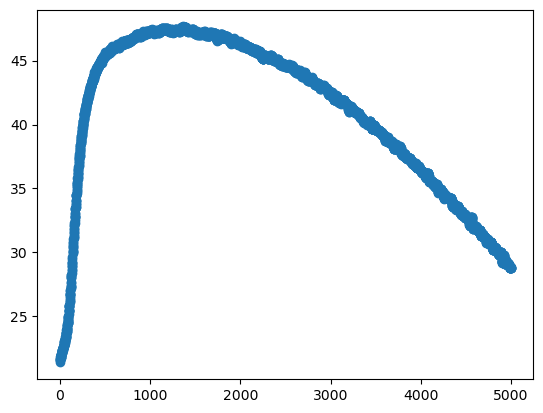

In [45]:
energy_history = utils.get_energy_history(current_path.iloc[2])
plt.plot(energy_history, 'o')

In [12]:
model, jax_params, input_dim = utils.load_model_from_path(current_path.iloc[0])
print(model)

ExponentialMLPwithPenalty(
    # attributes
    architecture = [10, 64, 64, 1]
    hidden_activation = tanh
    kernel_init = init
    bias_init = zeros
)


Shape of psi_values_array: (10, 200, 1)
Shape of psi_values_mean: (200,)
Shape of psi_values_std: (200,)


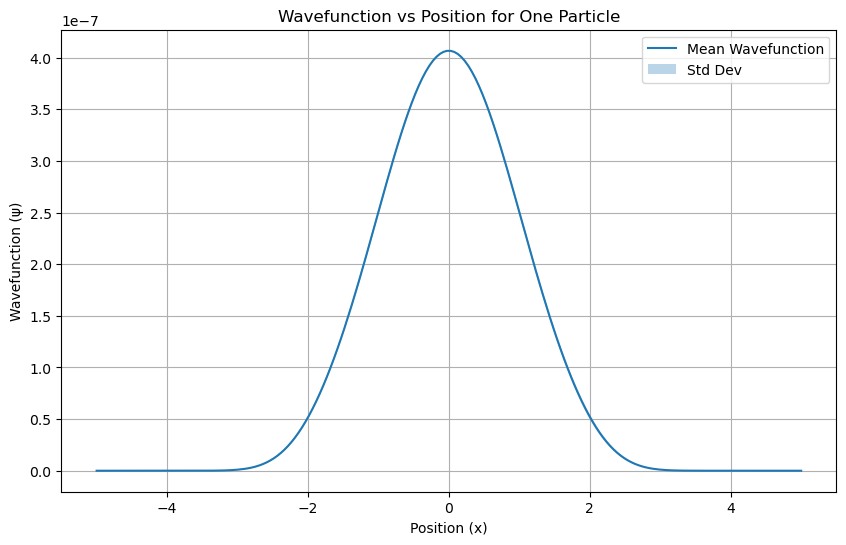

In [13]:
utils.plot_wavefunction_one_particle(model, jax_params, input_dim)

In [14]:
test_row.iloc[0]

total_energy                                                        4.890827
std                                                                 0.038843
training_time_seconds                                              37.066688
best_score                                                          4.968512
path                       out/20260211_142926/config_64_hu_2_l_10_partic...
training_batch_size                                                      500
sampler_step_size                                                        0.5
sampler_chain_length                                                     150
optimizer_learning_rate                                                 0.01
input_dim                                                                 10
hidden_dim                                                          [64, 64]
energy_per_particle                                                 0.489083
std_energy_per_particle                                             0.003884

In [49]:
df_normal_walkers.columns

Index(['total_energy', 'std', 'training_time_seconds', 'best_score', 'path',
       'training_batch_size', 'sampler_step_size', 'sampler_chain_length',
       'optimizer_learning_rate', 'input_dim', 'hidden_dim',
       'energy_per_particle', 'std_energy_per_particle',
       'best_score_per_particle'],
      dtype='str')

In [50]:
df_10p = df_normal_walkers[df_normal_walkers['input_dim'] == 10]
df_10p.head()

,total_energy,std,training_time_seconds,best_score,path,training_batch_size,sampler_step_size,sampler_chain_length,optimizer_learning_rate,input_dim,hidden_dim,energy_per_particle,std_energy_per_particle,best_score_per_particle
1,5.650299,1.682009,27.508885,9.014318,out/20260211_142926/config_4_hu_3_l_10_particl...,1000,0.50,125,0.001,10,"[4, 4, 4]",0.565030,0.168201,0.901432
2,4.518309,1.176057,16.415093,6.870423,out/20260211_142926/config_4_hu_1_l_10_particl...,500,0.05,125,0.010,10,[4],0.451831,0.117606,0.687042
3,4.970542,1.889289,18.872814,8.749120,out/20260211_142926/config_8_hu_1_l_10_particl...,1000,0.05,150,0.001,10,[8],0.497054,0.188929,0.874912
10,4.682015,0.486754,23.063409,5.655524,out/20260211_142926/config_16_hu_3_l_10_partic...,500,0.05,100,0.010,10,"[16, 16, 16]",0.468202,0.048675,0.565552
11,4.242856,3.528497,26.992406,11.299850,out/20260211_142926/config_16_hu_3_l_10_partic...,1000,0.10,100,0.001,10,"[16, 16, 16]",0.424286,0.352850,1.129985


# hidden units per layer vs energy per particle

In [81]:
BATCH_SIZE = 1000
STEP_SIZE = 0.1
CHAIN_LENGTH = 150
LEARNING_RATE = 0.01

def extract_hidden_units_per_layer_and_layers(row):
    architecture = list(map(int, row['hidden_dim'].strip('[]').split(',')))
    return architecture[0], len(architecture)

df_10p['hidden_units_per_layer'] = df_10p.apply(extract_hidden_units_per_layer_and_layers, axis=1, result_type='expand')[0]
df_10p['num_layers'] = df_10p.apply(extract_hidden_units_per_layer_and_layers, axis=1, result_type='expand')[1]
df_10p.head()

,total_energy,std,training_time_seconds,best_score,path,training_batch_size,sampler_step_size,sampler_chain_length,optimizer_learning_rate,input_dim,hidden_dim,energy_per_particle,std_energy_per_particle,best_score_per_particle,hidden_units_per_layer,num_layers
1,5.650299,1.682009,27.508885,9.014318,out/20260211_142926/config_4_hu_3_l_10_particl...,1000,0.50,125,0.001,10,"[4, 4, 4]",0.565030,0.168201,0.901432,4,3
2,4.518309,1.176057,16.415093,6.870423,out/20260211_142926/config_4_hu_1_l_10_particl...,500,0.05,125,0.010,10,[4],0.451831,0.117606,0.687042,4,1
3,4.970542,1.889289,18.872814,8.749120,out/20260211_142926/config_8_hu_1_l_10_particl...,1000,0.05,150,0.001,10,[8],0.497054,0.188929,0.874912,8,1
10,4.682015,0.486754,23.063409,5.655524,out/20260211_142926/config_16_hu_3_l_10_partic...,500,0.05,100,0.010,10,"[16, 16, 16]",0.468202,0.048675,0.565552,16,3
11,4.242856,3.528497,26.992406,11.299850,out/20260211_142926/config_16_hu_3_l_10_partic...,1000,0.10,100,0.001,10,"[16, 16, 16]",0.424286,0.352850,1.129985,16,3


In [82]:
study_df = df_10p[(df_10p["training_batch_size"]==BATCH_SIZE) & (df_10p["sampler_step_size"]==STEP_SIZE) & (df_10p["sampler_chain_length"]==CHAIN_LENGTH) & (df_10p["optimizer_learning_rate"]==LEARNING_RATE)]
study_df.head()

,total_energy,std,training_time_seconds,best_score,path,training_batch_size,sampler_step_size,sampler_chain_length,optimizer_learning_rate,input_dim,hidden_dim,energy_per_particle,std_energy_per_particle,best_score_per_particle,hidden_units_per_layer,num_layers
579,2.195760,0.580996,52.803852,3.357752,out/20260211_142926/config_64_hu_2_l_10_partic...,1000,0.1,150,0.01,10,"[64, 64]",0.219576,0.058100,0.335775,64,2
726,3.093547,1.049694,34.897456,5.192935,out/20260211_142926/config_32_hu_2_l_10_partic...,1000,0.1,150,0.01,10,"[32, 32]",0.309355,0.104969,0.519293,32,2
801,1.229059,0.541521,142.048925,2.312100,out/20260211_142926/config_128_hu_3_l_10_parti...,1000,0.1,150,0.01,10,"[128, 128, 128]",0.122906,0.054152,0.231210,128,3
1171,1.229896,0.544558,31.436409,2.319013,out/20260211_142926/config_128_hu_1_l_10_parti...,1000,0.1,150,0.01,10,[128],0.122990,0.054456,0.231901,128,1
1306,3.208322,1.117293,47.391046,5.442907,out/20260211_142926/config_32_hu_3_l_10_partic...,1000,0.1,150,0.01,10,"[32, 32, 32]",0.320832,0.111729,0.544291,32,3


## Plot hidden units vs energy per particle

Reading energy history from: out/20260211_142926/config_64_hu_2_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.1_stepsize/config_64_hu_2_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.1_stepsize
Reading energy history from: out/20260211_142926/config_64_hu_3_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.1_stepsize/config_64_hu_3_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.1_stepsize
Reading energy history from: out/20260211_142926/config_64_hu_1_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.1_stepsize/config_64_hu_1_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.1_stepsize
Reading energy history from: out/20260211_142926/config_32_hu_2_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.1_stepsize/config_32_hu_2_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.1_stepsize
Reading energy history from: out/20260211_142926/config_32_hu_3_l_10_particles_0.01_lr_1000_nchain_150_nstep_5000_epochs_0.1

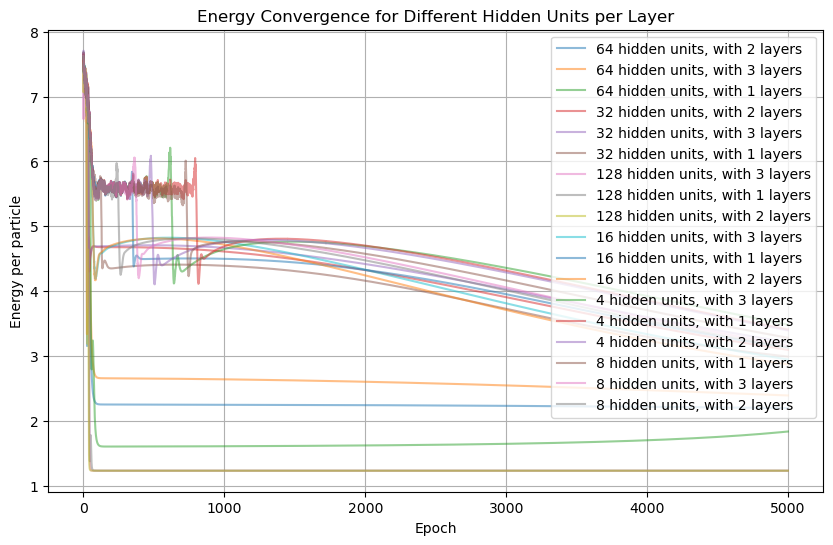

In [90]:
# plot energy convergence for different hidden units per layer
plt.figure(figsize=(10, 6))
for hidden_units in study_df['hidden_units_per_layer'].unique():
    subset = study_df[study_df['hidden_units_per_layer'] == hidden_units]
    energy_histories = []
    layers = []
    for index, row in subset.iterrows():
        path = row['path']
        layer = row['num_layers']
        energy_history = utils.get_energy_history(path)
        energy_histories.append(energy_history)
        layers.append(layer)
    # Pad energy histories to the same length
    max_length = max(len(eh) for eh in energy_histories)
    padded_energy_histories = [eh + [np.nan]*(max_length - len(eh)) for eh in energy_histories]
    # mean_energy_history = np.nanmean(padded_energy_histories, axis=0)
    # plt.plot(mean_energy_history, label=f'{hidden_units} hidden units/layer')
    for energy_history, layers in zip(padded_energy_histories, layers):
        plt.plot(energy_history, label=f'{hidden_units} hidden units, with {layers} layers', alpha=0.5)

plt.xlabel('Epoch')
plt.ylabel('Energy per particle')
plt.title('Energy Convergence for Different Hidden Units per Layer')
plt.legend()
plt.grid()
plt.show()